### 基于K-Means聚类与Prophet时序预测的重庆上市车企财务智能预警研究

#### ——赛力斯外部协同经营模式对标长安自主研发模式

一、数据获取
1. 获取财务报表数据：2016年Q1-2025年Q4
* `data/collect_financial_data.py` # 获取财务数据
* 获取8家对标车企（赛力斯★/长安汽车★/比亚迪/上汽集团/长城汽车/广汽集团/江淮汽车/北汽蓝谷）的资产负债表、利润表和现金流量表的年度数据，并保存为excel文件。
2. 获取车企销售数据：2023年Q1-2026年Q4
* `data/add_company_sales.py` # 添加公司销售数据
* `data/extract_sales_structure.py` # 获取销售结构数据

二、数据探索

1. 财务指标

（1）数据读取   

In [4]:
import pandas as pd
from pathlib import Path

data_dir = Path('data')
all_data = {
    file.stem.replace('_财务数据', ''): pd.read_excel(file)
    for file in data_dir.glob('*_财务数据.xlsx')
}
# 加载
for company, df in all_data.items():
    print(f"{company}: {len(df)} 条记录")
list(all_data.values())[0].head() # 预览

000625_长安汽车: 69 条记录
002594_比亚迪: 64 条记录
600104_上汽集团: 69 条记录
600418_江淮汽车: 61 条记录
600733_北汽蓝谷: 61 条记录
601127_赛力斯: 63 条记录
601238_广汽集团: 69 条记录
601633_长城汽车: 65 条记录


,Unnamed: 0,2016年报,2016Q1,2016Q2,2016Q3,2017年报,2017Q1,2017Q2,2017Q3,2018年报,...,2023Q2,2023Q3,2024年报,2024Q1,2024Q2,2024Q3,2025年报,2025Q1,2025Q2,2025Q3
0,货币资金,2.478300e+10,1.871700e+10,2.135800e+10,2.510300e+10,2.263200e+10,2.832800e+10,2.788200e+10,2.399200e+10,9.981000e+09,...,6.598600e+10,7.219200e+10,6.418200e+10,7.006800e+10,7.093900e+10,7.000500e+10,5.402200e+10,6.012900e+10,5.283000e+10,5.524100e+10
1,交易性金融资产,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.620000e+08,1.570000e+08,1.550000e+08,1.440000e+08,1.530000e+08,1.670000e+08,NaN,1.500000e+08,1.620000e+08,1.024000e+05
2,应收账款,1.499000e+09,1.270000e+09,1.480000e+09,1.518000e+09,1.807000e+09,2.427000e+09,1.900000e+09,1.996000e+09,1.409000e+09,...,2.477000e+09,2.669000e+09,3.398000e+09,3.277000e+09,2.989000e+09,4.226000e+09,4.197000e+09,5.021000e+09,6.628000e+09,7.216000e+09
3,应收票据及应收账款,3.050100e+10,2.414100e+10,2.131300e+10,2.162200e+10,3.096300e+10,2.588000e+10,2.363500e+10,2.336100e+10,2.197100e+10,...,3.644100e+10,3.804700e+10,4.897900e+10,3.698200e+10,3.698500e+10,3.344300e+10,3.719500e+10,4.285000e+10,3.218500e+10,2.773400e+10
4,预付款项,1.061000e+09,6.700000e+08,9.910000e+08,8.800000e+08,1.102000e+09,1.323000e+09,1.274000e+09,1.832000e+09,8.660000e+08,...,6.620000e+08,9.880000e+08,5.070000e+08,4.820000e+08,5.830000e+08,4.560000e+08,4.920000e+08,4.360000e+08,4.000000e+08,7.940000e+08


(2) 报表合并

In [9]:
def integrate_financial_data(company_code):          # 参数是 company_code，不是 name
    file_path = f'data/{company_code}_财务数据.xlsx'
    
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    
    data = pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)
    print(f'完成: {len(data)} 期 × {len(data.columns)} 个指标')
    return data  

# 查看
companies = [f.stem.replace('_财务数据','') for f in Path('data').glob('*_财务数据.xlsx')]
print('可用公司:', companies)

data = integrate_financial_data('601127_赛力斯')
data.info()
data.head()
#data.to_csv('data/601127_赛力斯_财务数据_merged.csv', index=True, encoding='utf-8-sig')  # 保存为 CSV 文件

可用公司: ['000625_长安汽车', '002594_比亚迪', '600104_上汽集团', '600418_江淮汽车', '600733_北汽蓝谷', '601127_赛力斯', '601238_广汽集团', '601633_长城汽车']
完成: 40 期 × 154 个指标
<class 'pandas.DataFrame'>
Index: 40 entries, 2016年报 to 2025Q3
Columns: 154 entries, 一、营业总收入_利润 to 间接法-现金及现金等价物净增加额_现金流
dtypes: float64(154)
memory usage: 48.4+ KB


,一、营业总收入_利润,营业收入_利润,税金及附加_利润,销售费用_利润,管理费用_利润,研发费用_利润,财务费用_利润,其中：利息费用_利润,其中：利息收入_利润,投资收益_利润,...,投资损失_现金流,递延所得税资产减少_现金流,递延所得税负债增加_现金流,存货的减少_现金流,经营性应收项目的减少_现金流,经营性应付项目的增加_现金流,间接法-经营活动产生的现金流量净额_现金流,现金的期末余额_现金流,减：现金的期初余额_现金流,间接法-现金及现金等价物净增加额_现金流
2016年报,1.619243e+10,1.619243e+10,5.070655e+08,1.040867e+09,8.576498e+08,0.000000e+00,31223587.42,0.000000e+00,0.000000e+00,17085648.52,...,-17085600.0,-2747300.0,-2803400.0,-398000000.0,-3.166000e+09,3.396000e+09,1.146000e+09,2.354000e+09,7.830000e+08,1.571000e+09
2016Q1,3.192494e+09,3.192494e+09,8.975824e+07,2.354520e+08,1.904555e+08,0.000000e+00,19150137.50,0.000000e+00,0.000000e+00,3113381.63,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2016Q2,6.335556e+09,6.335556e+09,1.679867e+08,4.499726e+08,3.629218e+08,0.000000e+00,39083090.27,0.000000e+00,0.000000e+00,4811555.19,...,-4811600.0,2414900.0,-1409500.0,-94636200.0,-9.450730e+07,2.320000e+08,6.140000e+08,1.813000e+09,7.830000e+08,1.030000e+09
2016Q3,1.020144e+10,1.020144e+10,2.830919e+08,7.015685e+08,5.480660e+08,0.000000e+00,49897945.70,0.000000e+00,0.000000e+00,13988970.02,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2017年报,2.193376e+10,2.193376e+10,6.996699e+08,1.282389e+09,9.138462e+08,4.678123e+08,30211619.41,1.378618e+08,1.179849e+08,14875439.06,...,-14875400.0,-7041700.0,-2344900.0,-242000000.0,-9.310000e+08,1.340000e+08,9.970000e+08,4.366000e+09,2.354000e+09,2.012000e+09


(3) 插到新table

In [10]:
from pathlib import Path
import pandas as pd

def integrate_financial_data(company_code):
    file_path = f'data/{company_code}_财务数据.xlsx'
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    return pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)

# 逐家公司追加合并报表 sheet
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    data = integrate_financial_data(code)
    with pd.ExcelWriter(fp, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        data.to_excel(writer, sheet_name='合并报表', index=True)
    print(f'✅ {code}: 已追加合并报表 ({len(data)}期×{len(data.columns)}指标)')


✅ 000625_长安汽车: 已追加合并报表 (40期×160指标)
✅ 002594_比亚迪: 已追加合并报表 (40期×159指标)
✅ 600104_上汽集团: 已追加合并报表 (40期×167指标)
✅ 600418_江淮汽车: 已追加合并报表 (40期×155指标)
✅ 600733_北汽蓝谷: 已追加合并报表 (40期×149指标)
✅ 601127_赛力斯: 已追加合并报表 (40期×154指标)
✅ 601238_广汽集团: 已追加合并报表 (40期×169指标)
✅ 601633_长城汽车: 已追加合并报表 (40期×160指标)


（4） 静态财务指标
* 盈利能力、营运能力、偿债能力、成长能力

In [23]:
import numpy as np

def financial_ratio(name, data):
    """计算15个财务指标（批量构建，无 PerformanceWarning）"""
    col = {
        '营收': '营业收入_利润', '营成': '营业成本_利润', '营利': '营业利润_利润',
        '净利': '净利润_利润', '归母净利': '归属于母公司所有者的净利润_利润',
        '利息': '其中：利息费用_利润', '存货': '存货_资产', '资产': '资产合计_资产',
        '负债': '负债合计_资产', '货币资金': '货币资金_资产', '应收': '应收账款_资产',
        '流资': '流动资产合计_资产', '流负': '流动负债合计_资产',
        '预付': '预付款项_资产', '权益': '归属于母公司所有者权益合计_资产',
    }
    
    # 所有新列一次性构建，避免 DataFrame 碎片化
    new_cols = {}
    new_cols['息税前利润'] = data[col['营利']] + data[col['利息']]
    new_cols['毛利率'] = 1 - data[col['营成']] / data[col['营收']]
    new_cols['营业利润率'] = data[col['营利']] / data[col['营收']]
    new_cols['净利润率'] = data[col['净利']] / data[col['营收']]
    new_cols['净资产收益率'] = 2 * data[col['归母净利']] / (
        data[col['权益']] + data[col['权益']].shift(1))
    new_cols['存货周转率'] = 2 * data[col['营成']] / (
        data[col['存货']] + data[col['存货']].shift(1))
    new_cols['总资产周转率'] = 2 * data[col['营收']] / (
        data[col['资产']] + data[col['资产']].shift(1))
    new_cols['应收账款周转率'] = 2 * data[col['营收']] / (
        data[col['应收']] + data[col['应收']].shift(1))
    new_cols['流动比率'] = data[col['流资']] / data[col['流负']]
    new_cols['速动比率'] = (data[col['流资']] - data[col['存货']] - data[col['预付']]) / data[col['流负']]
    new_cols['利息保障倍数'] = new_cols['息税前利润'] / data[col['利息']]
    new_cols['资产负债率'] = data[col['负债']] / data[col['资产']]
    new_cols['货币资金占比'] = data[col['货币资金']] / data[col['资产']]
    new_cols['营业收入增长率'] = data[col['营收']] / data[col['营收']].shift(1) - 1
    new_cols['营业利润增长率'] = data[col['营利']] / data[col['营利']].shift(1) - 1
    new_cols['净利润增长率'] = data[col['净利']] / data[col['净利']].shift(1) - 1
    
    # 一次 concat 完成，无警告
    df_new = pd.concat(new_cols, axis=1)
    
    cols = ['毛利率','营业利润率','净利润率','净资产收益率',
            '存货周转率','总资产周转率','应收账款周转率',
            '流动比率','速动比率','利息保障倍数','资产负债率','货币资金占比',
            '营业收入增长率','营业利润增长率','净利润增长率']
    df = df_new[cols].iloc[1:].copy()
    df.index = data.index[1:]
    df[np.isinf(df)] = 0
    
    with pd.ExcelWriter(f'data/{name}_财务数据.xlsx',
                        engine='openpyxl', mode='a',
                        if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name='财务指标表', index=True)
    
    print(f'✅ {name}: 财务指标表已保存 ({len(df)}期×{len(df.columns)}指标)')
    return df


# ============ 使用 ============
data = integrate_financial_data('601127_赛力斯')
df_ratio = financial_ratio(name='601127_赛力斯', data=data)
df_ratio.head()


✅ 601127_赛力斯: 财务指标表已保存 (39期×15指标)


,毛利率,营业利润率,净利润率,净资产收益率,存货周转率,总资产周转率,应收账款周转率,流动比率,速动比率,利息保障倍数,资产负债率,货币资金占比,营业收入增长率,营业利润增长率,净利润增长率
2016Q1,0.043866,0.044842,0.042124,0.035970,5.595694,0.188598,16.246791,NaN,NaN,0.000000,0.762251,0.000000,-0.802840,-0.799713,-0.788253
2016Q2,0.035776,0.036536,0.034175,0.062562,15.028030,0.433749,30.241316,0.906216,0.810236,0.000000,0.726142,0.196196,0.984516,0.616925,0.610027
2016Q3,0.031950,0.033321,0.031242,0.081030,11.777589,0.629952,24.700825,0.902486,0.792878,0.000000,0.752065,0.191288,0.610189,0.468511,0.472005
2017年报,0.057857,0.063177,0.050213,0.173452,18.769072,1.072346,32.160944,0.996867,0.882267,11.051469,0.754407,0.247154,1.150065,3.076576,2.455630
2017Q1,0.059936,0.060224,0.048794,0.045958,3.692621,0.260812,8.833686,0.894994,0.770151,0.000000,0.772137,0.225941,-0.732175,-0.744695,-0.739740


In [24]:
import numpy as np
from pathlib import Path
#批量处理8家公司
all_ratios = {}

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    print(f'处理: {code} ... ', end='')
    
    # 读取
    xl = pd.ExcelFile(fp)
    if '合并报表' in xl.sheet_names:
        data = pd.read_excel(xl, '合并报表', index_col=0)
    else:
        data = integrate_financial_data(code)
    
    # 15个指标
    df_ratio = financial_ratio(name=code, data=data)
    all_ratios[code] = df_ratio
    print(f'OK ({len(df_ratio)}期)')

print(f'\n 完成: {len(all_ratios)} 家公司')

处理: 000625_长安汽车 ... ✅ 000625_长安汽车: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 002594_比亚迪 ... ✅ 002594_比亚迪: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600104_上汽集团 ... ✅ 600104_上汽集团: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600418_江淮汽车 ... ✅ 600418_江淮汽车: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 600733_北汽蓝谷 ... ✅ 600733_北汽蓝谷: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601127_赛力斯 ... ✅ 601127_赛力斯: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601238_广汽集团 ... ✅ 601238_广汽集团: 财务指标表已保存 (39期×15指标)
OK (39期)
处理: 601633_长城汽车 ... ✅ 601633_长城汽车: 财务指标表已保存 (39期×15指标)
OK (39期)

 完成: 8 家公司


三、财务分析

（1） K-Means 聚类分析（8家车企风险分群）

  K-Means 聚类结果 (K=3)
  群0: ['广汽集团']
    均值: 毛利率=-15.7%, 净利率=-12.0%, ROE=-8.0%, 负债率=49.0%, 周转率=0.44
  群1: ['长安汽车', '比亚迪', '上汽集团', '江淮汽车', '赛力斯', '长城汽车']
    均值: 毛利率=1.4%, 净利率=2.2%, ROE=7.4%, 负债率=67.3%, 周转率=0.98
  群2: ['北汽蓝谷']
    均值: 毛利率=-21.5%, 净利率=-22.8%, ROE=-332.2%, 负债率=88.5%, 周转率=0.84

--- 核心结论 ---
  赛力斯 → 群1，同群: ['长安汽车', '比亚迪', '上汽集团', '江淮汽车', '赛力斯', '长城汽车']
  长安汽车 → 群1，同群: ['长安汽车', '比亚迪', '上汽集团', '江淮汽车', '赛力斯', '长城汽车']


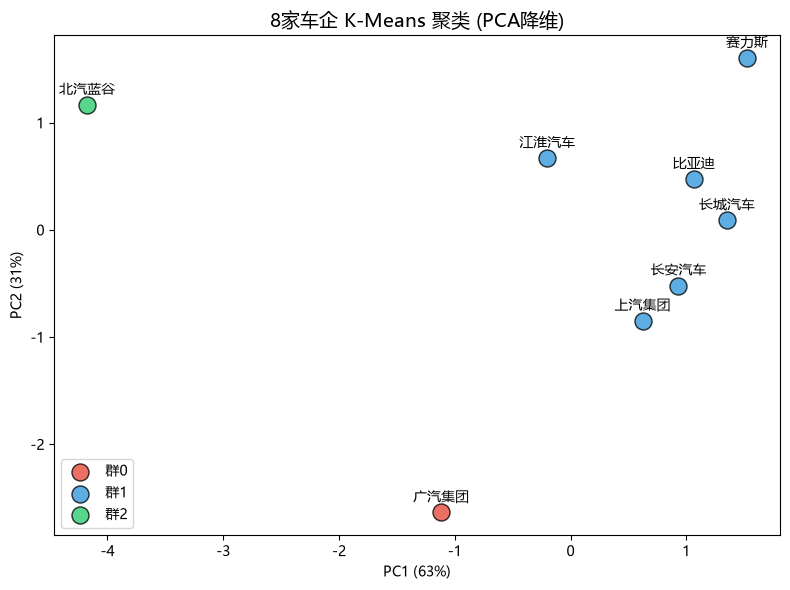

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ============ 构建特征矩阵 ============
# 取最新年报的5个核心指标
FEATURES = ['毛利率', '净利润率', '净资产收益率', '资产负债率', '总资产周转率']

records = []
for code, df_ratio in all_ratios.items():
    # 找最新一期年报
    annual_idx = [i for i in df_ratio.index if '年报' in str(i)]
    if not annual_idx:
        continue
    latest = annual_idx[-1]
    row = {'code': code, 'name': code.split('_')[1], 'period': latest}
    for f in FEATURES:
        row[f] = float(df_ratio.loc[latest, f]) if latest in df_ratio.index else None
    if all(row[f] is not None and not np.isnan(row[f]) for f in FEATURES):
        records.append(row)

df_kmeans = pd.DataFrame(records)
X = df_kmeans[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

# ============ K-Means (K=3) ============
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_kmeans['cluster'] = km.fit_predict(X_scaled)

print('='*60)
print('  K-Means 聚类结果 (K=3)')
print('='*60)
for c in range(3):
    members = df_kmeans[df_kmeans['cluster'] == c]['name'].tolist()
    # 计算该群的平均特征
    avg = df_kmeans[df_kmeans['cluster'] == c][FEATURES].mean()
    print(f'  群{c}: {members}')
    print(f'    均值: 毛利率={avg["毛利率"]:.1%}, 净利率={avg["净利润率"]:.1%}, '
          f'ROE={avg["净资产收益率"]:.1%}, 负债率={avg["资产负债率"]:.1%}, 周转率={avg["总资产周转率"]:.2f}')

# ============ 重点关注 ============
print('\n--- 核心结论 ---')
for target in ['赛力斯', '长安汽车']:
    row = df_kmeans[df_kmeans['name'] == target]
    if len(row) > 0:
        c = row['cluster'].values[0]
        peers = df_kmeans[df_kmeans['cluster'] == c]['name'].tolist()
        print(f'  {target} → 群{c}，同群: {peers}')

# ============ PCA 可视化 ============
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E74C3C', '#3498DB', '#2ECC71']
for c in range(3):
    mask = df_kmeans['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c], s=150,
               label=f'群{c}', edgecolors='black', alpha=0.8)
for i, name in enumerate(df_kmeans['name']):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=10, ha='center', xytext=(0, 8),
                textcoords='offset points')
ax.set_title('8家车企 K-Means 聚类 (PCA降维)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.legend()
plt.tight_layout()
plt.show()

（2）孤立森林异常检测

  孤立森林 异常检测
  长安汽车  : ✅ 正常 (得分=0.162)
  比亚迪   : ✅ 正常 (得分=0.171)
  上汽集团  : ✅ 正常 (得分=0.161)
  江淮汽车  : ✅ 正常 (得分=0.084)
  北汽蓝谷  : ⚠️ 异常 (得分=-0.092)
  赛力斯   : ✅ 正常 (得分=0.085)
  广汽集团  : ⚠️ 异常 (得分=-0.004)
  长城汽车  : ✅ 正常 (得分=0.161)

异常企业: ['北汽蓝谷', '广汽集团']


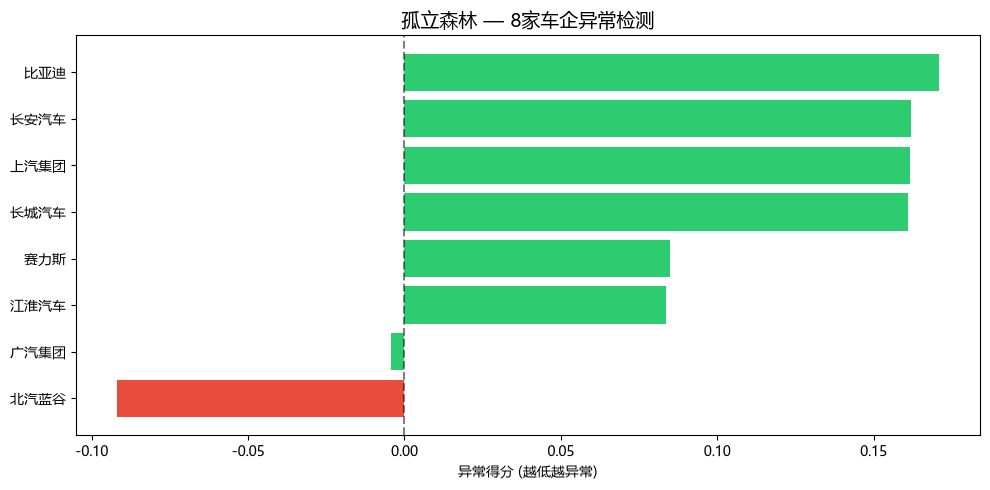

In [18]:
from sklearn.ensemble import IsolationForest

# ============ 孤立森林 ============
iso = IsolationForest(contamination=0.15, random_state=42)
anomaly_labels = iso.fit_predict(X_scaled)
anomaly_scores = iso.decision_function(X_scaled)

df_kmeans['anomaly'] = anomaly_labels
df_kmeans['anomaly_score'] = anomaly_scores

print('='*60)
print('  孤立森林 异常检测')
print('='*60)
for _, row in df_kmeans.iterrows():
    flag = '⚠️ 异常' if row['anomaly'] == -1 else '✅ 正常'
    print(f'  {row["name"]:<6s}: {flag} (得分={row["anomaly_score"]:.3f})')

print(f'\n异常企业: {df_kmeans[df_kmeans["anomaly"]==-1]["name"].tolist()}')

# ============ 可视化 ============
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = df_kmeans.sort_values('anomaly_score')
colors = ['#E74C3C' if s < -0.05 else '#2ECC71' for s in sorted_df['anomaly_score']]
ax.barh(range(len(sorted_df)), sorted_df['anomaly_score'], color=colors)
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df['name'].values)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('异常得分 (越低越异常)')
ax.set_title('孤立森林 — 8家车企异常检测', fontsize=14)
plt.tight_layout()
plt.show()


（3）Prophet 时序预测（赛力斯 vs 长安）


  赛力斯（未来 12 个月预测）


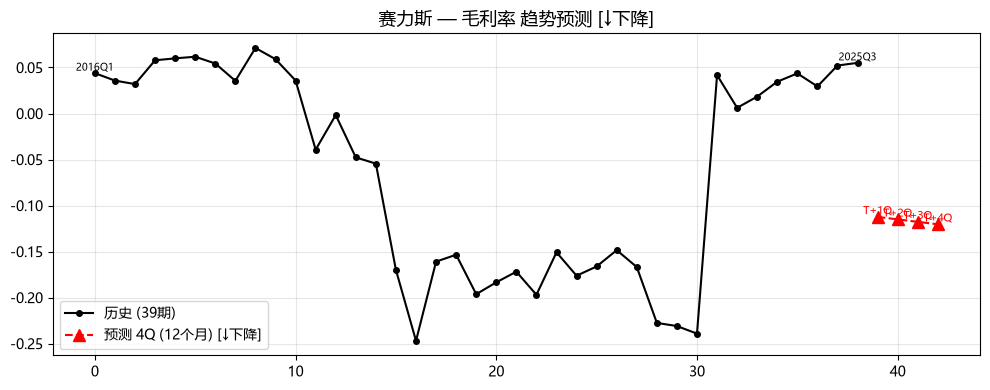

  赛力斯 毛利率: ↓下降
    当前(2025Q3): 0.0550
    预测(4Q后): -0.1204
    变动: -318.7%


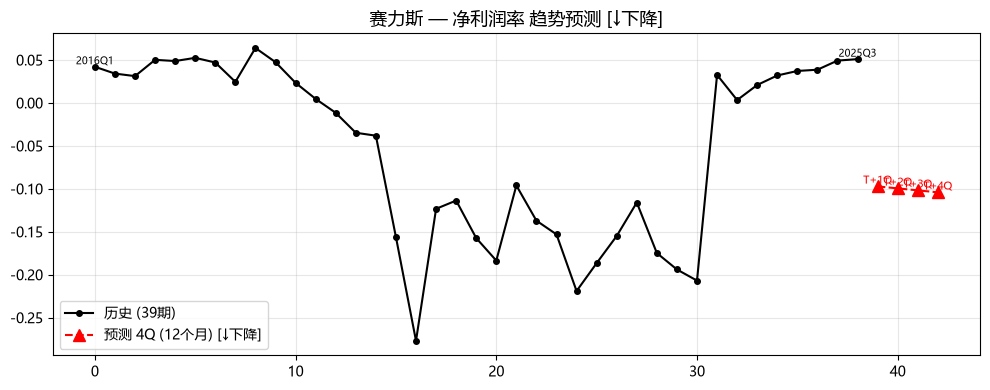

  赛力斯 净利润率: ↓下降
    当前(2025Q3): 0.0510
    预测(4Q后): -0.1041
    变动: -304.1%


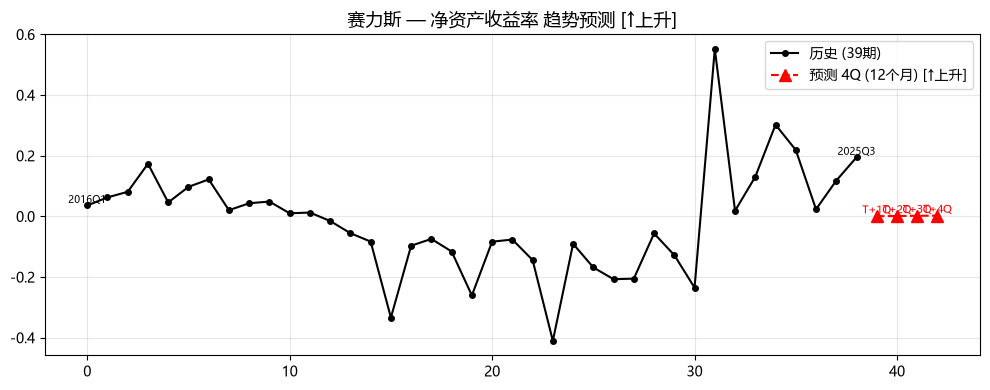

  赛力斯 净资产收益率: ↑上升
    当前(2025Q3): 0.1947
    预测(4Q后): 0.0025
    变动: -98.7%


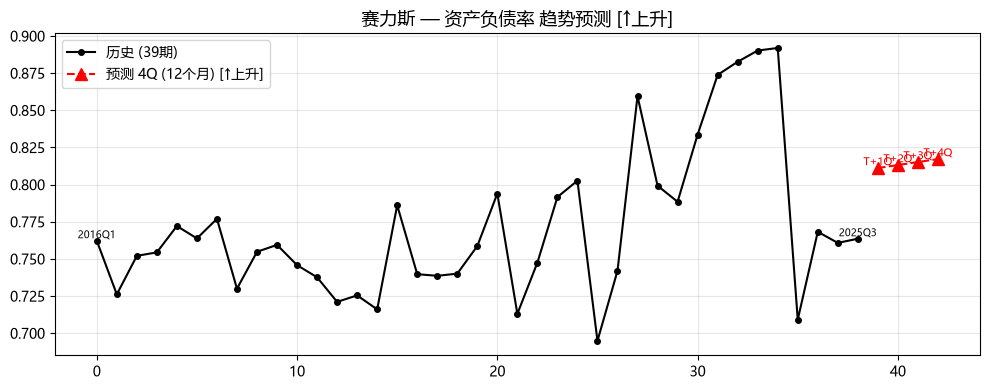

  赛力斯 资产负债率: ↑上升
    当前(2025Q3): 0.7636
    预测(4Q后): 0.8172
    变动: +7.0%

  长安汽车（未来 12 个月预测）


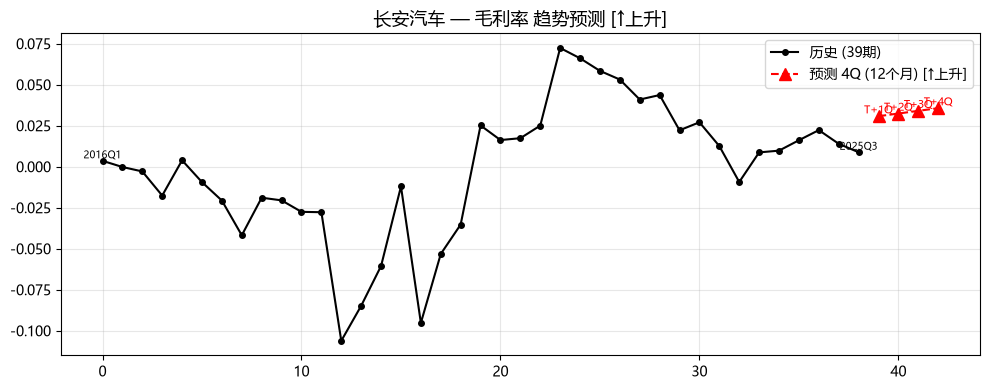

  长安汽车 毛利率: ↑上升
    当前(2025Q3): 0.0088
    预测(4Q后): 0.0357
    变动: +306.2%


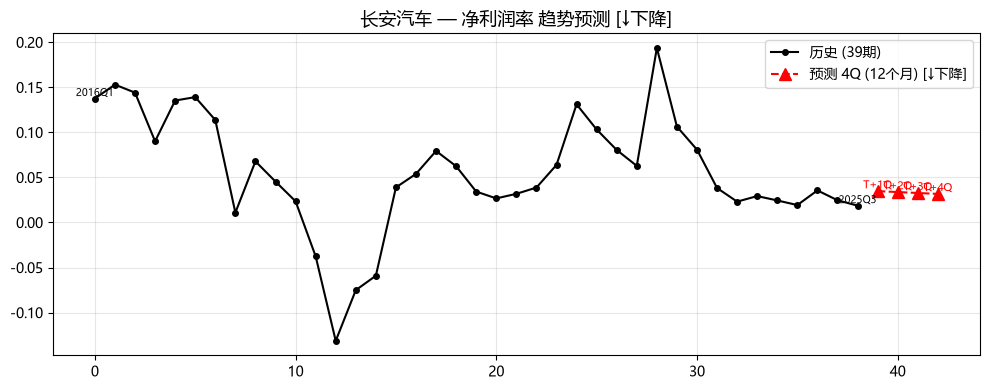

  长安汽车 净利润率: ↓下降
    当前(2025Q3): 0.0187
    预测(4Q后): 0.0317
    变动: +69.8%


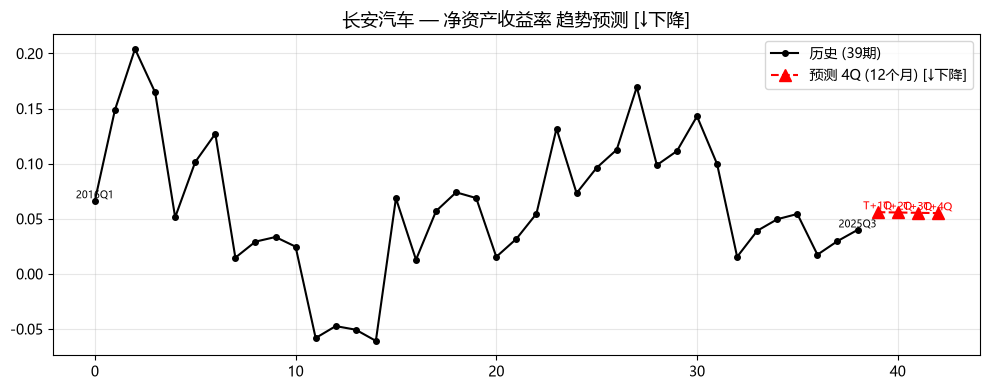

  长安汽车 净资产收益率: ↓下降
    当前(2025Q3): 0.0399
    预测(4Q后): 0.0551
    变动: +38.1%


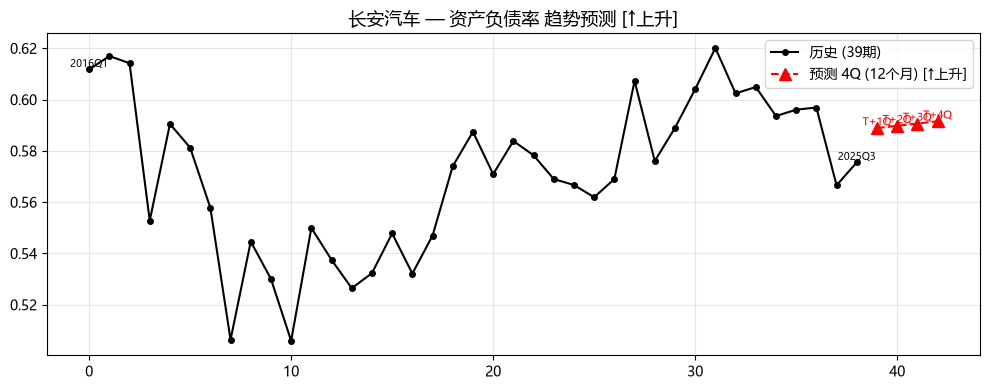

  长安汽车 资产负债率: ↑上升
    当前(2025Q3): 0.5755
    预测(4Q后): 0.5915
    变动: +2.8%


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

def simple_forecast(code, metric_col, forecast_quarters=4):
    """
    季度级趋势预测：用全部季度数据拟合线性趋势，预测未来 N 个季度（默认4期=12个月）
    """
    df_ratio = all_ratios[code]
    name = code.split('_')[1]
    
    # 取所有季度数据（包含 Q1/Q2/Q3/年报）
    series = df_ratio[metric_col].dropna()
    if len(series) < 8:
        print(f'  {name} {metric_col}: 数据不足({len(series)})')
        return
    
    # 转换为时间序号
    series = series.copy()
    x_idx = np.arange(len(series)).reshape(-1, 1)
    y = series.values
    
    model = LinearRegression().fit(x_idx, y)
    direction = '↑上升' if model.coef_[0] > 0 else '↓下降'
    
    # 预测未来 N 个季度
    future_idx = np.arange(len(series), len(series) + forecast_quarters).reshape(-1, 1)
    pred = model.predict(future_idx)
    
    # 生成未来季度标签
    last_label = series.index[-1]  # 如 '2025Q3' 或 '2025年报'
    # 简化为数字序号标注
    future_labels = [f'T+{i+1}Q' for i in range(forecast_quarters)]  # T+1Q, T+2Q, ...
    
    # 可视化
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(series)), y, 'ko-', markersize=4, label=f'历史 ({len(series)}期)')
    ax.plot(range(len(series), len(series) + forecast_quarters), pred,
            'r^--', markersize=8, label=f'预测 {forecast_quarters}Q ({forecast_quarters*3}个月) [{direction}]')
    # 标注几个关键点
    for i in [0, len(series)-1]:
        ax.annotate(series.index[i], (i, y[i]), fontsize=7, ha='center', va='bottom')
    for i, lbl in enumerate(future_labels):
        ax.annotate(lbl, (len(series)+i, pred[i]), fontsize=8, ha='center', va='bottom', color='red')
    
    ax.set_title(f'{name} — {metric_col} 趋势预测 [{direction}]', fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 输出：当前最新值、预测末值、变化幅度
    change_pct = (pred[-1] - y[-1]) / abs(y[-1]) * 100 if y[-1] != 0 else 0
    print(f'  {name} {metric_col}: {direction}')
    print(f'    当前({series.index[-1]}): {y[-1]:.4f}')
    print(f'    预测({forecast_quarters}Q后): {pred[-1]:.4f}')
    print(f'    变动: {change_pct:+.1f}%')


# ============ 赛力斯 vs 长安 预测 (4Q = 12个月) ============
METRICS = ['毛利率', '净利润率', '净资产收益率', '资产负债率']
FORECAST_Q = 4   # ← 改这里：2=6个月, 4=12个月

for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios:
        continue
    print(f'\n{"="*50}')
    print(f'  {code.split("_")[1]}（未来 {FORECAST_Q*3} 个月预测）')
    print(f'{"="*50}')
    for metric in METRICS:
        simple_forecast(code, metric, forecast_quarters=FORECAST_Q)

13:52:02 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 



  赛力斯（未来 12 个月预测）
  ⚠️ Prophet 失败，降级线性回归


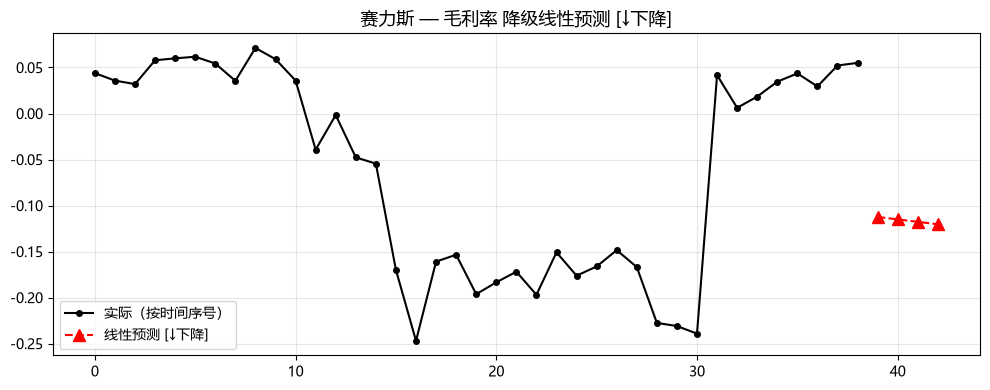

  赛力斯 毛利率: ↓下降
    当前: 0.0550  →  预测4Q后: -0.1204
    变动: -318.7%


13:52:03 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  ⚠️ Prophet 失败，降级线性回归


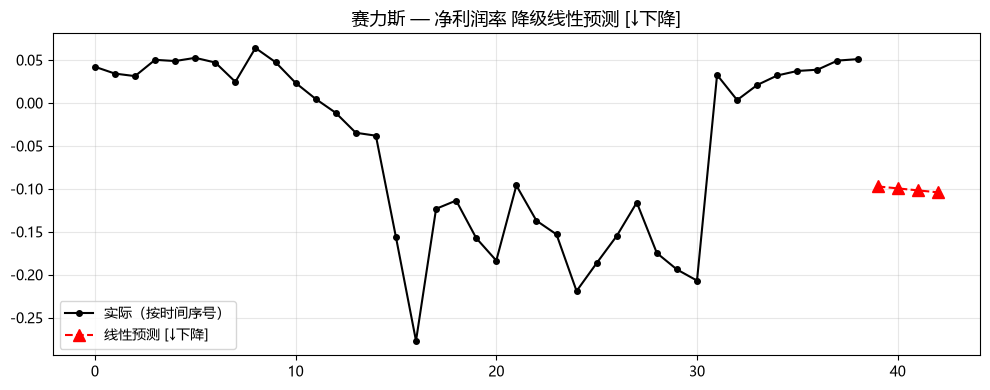

  赛力斯 净利润率: ↓下降
    当前: 0.0510  →  预测4Q后: -0.1041
    变动: -304.1%


13:52:03 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  ⚠️ Prophet 失败，降级线性回归


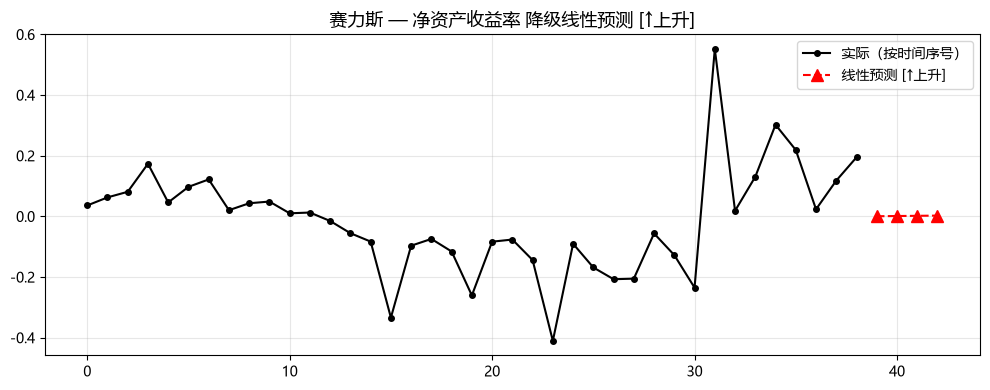

  赛力斯 净资产收益率: ↑上升
    当前: 0.1947  →  预测4Q后: 0.0025
    变动: -98.7%


13:52:04 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  ⚠️ Prophet 失败，降级线性回归


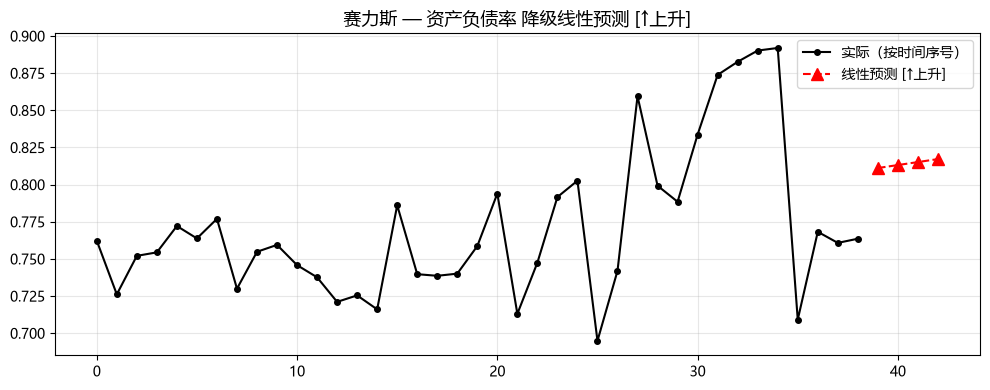

13:52:04 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  赛力斯 资产负债率: ↑上升
    当前: 0.7636  →  预测4Q后: 0.8172
    变动: +7.0%

  长安汽车（未来 12 个月预测）
  ⚠️ Prophet 失败，降级线性回归


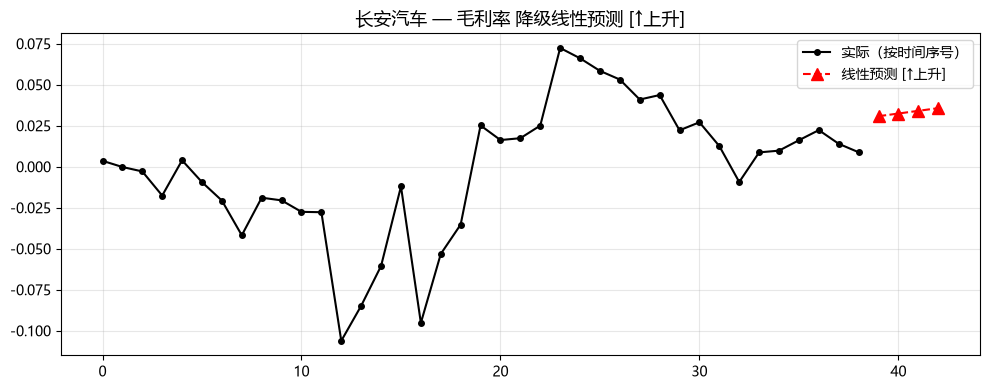

13:52:04 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  长安汽车 毛利率: ↑上升
    当前: 0.0088  →  预测4Q后: 0.0357
    变动: +306.2%
  ⚠️ Prophet 失败，降级线性回归


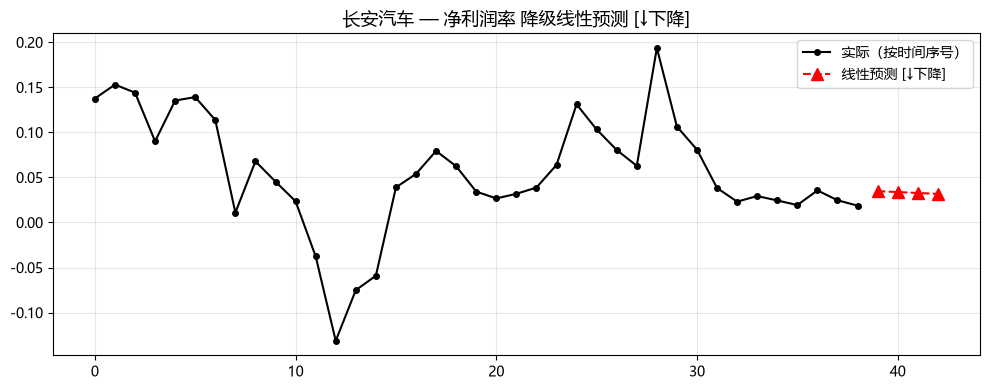

13:52:05 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  长安汽车 净利润率: ↓下降
    当前: 0.0187  →  预测4Q后: 0.0317
    变动: +69.8%
  ⚠️ Prophet 失败，降级线性回归


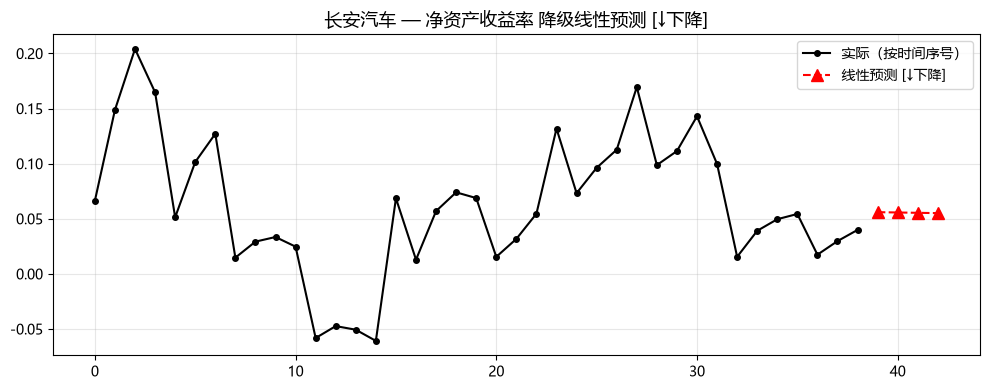

13:52:05 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


  长安汽车 净资产收益率: ↓下降
    当前: 0.0399  →  预测4Q后: 0.0551
    变动: +38.1%
  ⚠️ Prophet 失败，降级线性回归


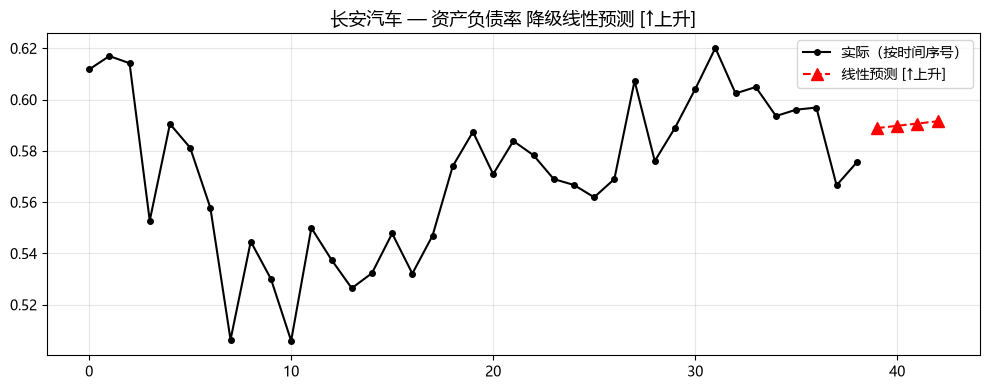

  长安汽车 资产负债率: ↑上升
    当前: 0.5755  →  预测4Q后: 0.5915
    变动: +2.8%


In [38]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

def prophet_forecast(code, metric_col, forecast_quarters=4):
    """
    Prophet 时序预测：未来 6-12 个月（2-4 个季度）
    Prophet 失败时自动降级为线性回归
    """
    df_ratio = all_ratios[code]
    name = code.split('_')[1]

    # ---- 准备数据 ----
    df_p = df_ratio[[metric_col]].reset_index()
    df_p['ds'] = pd.to_datetime(
        df_p['index'].str.replace('年报', '-12-31')
                     .str.replace('Q1', '-03-31')
                     .str.replace('Q2', '-06-30')
                     .str.replace('Q3', '-09-30'),
        errors='coerce')
    df_p = df_p.rename(columns={metric_col: 'y'}).dropna(subset=['ds', 'y'])
    df_p = df_p[df_p['y'] != 0].copy()  # 去零值

    if len(df_p) < 10:
        print(f'  {name} {metric_col}: 有效数据不足 ({len(df_p)}条)')
        return

    # ---- Prophet ----
    try:
        m = Prophet(growth='linear', yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False,
                    seasonality_mode='additive')
        m.fit(df_p[['ds', 'y']])
        future = m.make_future_dataframe(periods=forecast_quarters, freq='QE')  # QE not Q
        forecast = m.predict(future)

        hist_end = forecast[forecast['ds'] <= df_p['ds'].max()]['trend'].iloc[-1]
        pred_end = forecast['trend'].iloc[-1]
        direction = '↑上升' if pred_end > hist_end else '↓下降'
        change_pct = (forecast['yhat'].iloc[-1] - df_p['y'].iloc[-1]) / abs(df_p['y'].iloc[-1]) * 100

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(df_p['ds'], df_p['y'], 'k.', markersize=5, label='实际')
        ax.plot(forecast['ds'], forecast['yhat'], 'b-', linewidth=2, label='预测')
        ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                         color='b', alpha=0.12, label='置信区间')
        ax.set_title(f'{name} — {metric_col} Prophet预测 [{direction}]', fontsize=13)
        ax.legend(); plt.tight_layout(); plt.show()

        print(f'  {name} {metric_col}: {direction}')
        print(f'    当前: {df_p["y"].iloc[-1]:.4f}  →  预测{forecast_quarters}Q后: {forecast["yhat"].iloc[-1]:.4f}')
        print(f'    变动: {change_pct:+.1f}%')

    except Exception:
        # ======== 降级：线性回归 ========
        print(f'  ⚠️ Prophet 失败，降级线性回归')
        x_idx = np.arange(len(df_p)).reshape(-1, 1)
        y = df_p['y'].values
        lr = LinearRegression().fit(x_idx, y)
        direction = '↑上升' if lr.coef_[0] > 0 else '↓下降'
        future_x = np.arange(len(df_p), len(df_p) + forecast_quarters).reshape(-1, 1)
        pred = lr.predict(future_x)
        change_pct = (pred[-1] - y[-1]) / abs(y[-1]) * 100 if y[-1] != 0 else 0

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(range(len(y)), y, 'ko-', markersize=4, label='实际（按时间序号）')
        ax.plot(range(len(y), len(y) + forecast_quarters), pred,
                'r^--', markersize=8, label=f'线性预测 [{direction}]')
        ax.set_title(f'{name} — {metric_col} 降级线性预测 [{direction}]', fontsize=13)
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        print(f'  {name} {metric_col}: {direction}')
        print(f'    当前: {y[-1]:.4f}  →  预测{forecast_quarters}Q后: {pred[-1]:.4f}')
        print(f'    变动: {change_pct:+.1f}%')


# ============ 运行 ============
METRICS = ['毛利率', '净利润率', '净资产收益率', '资产负债率']
FORECAST_Q = 4   # 2=6个月，4=12个月

for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios:
        continue
    print(f'\n{"="*50}')
    print(f'  {code.split("_")[1]}（未来 {FORECAST_Q*3} 个月预测）')
    print(f'{"="*50}')
    for metric in METRICS:
        prophet_forecast(code, metric, forecast_quarters=FORECAST_Q)


（4） Z-score 破产预警 + 沃尔评分排名

In [34]:
zscore_data = {}
wolle_data = {}

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    name = code.split('_')[1]
    xl = pd.ExcelFile(fp)
    
    if '财务分析指标' not in xl.sheet_names:
        continue
    
    df_d = pd.read_excel(xl, '财务分析指标', index_col=0)  # index=报告期
    # FIX: 找 index 中含 "年报" 的行（不是 columns！）
    annual_rows = [i for i in df_d.index if '年报' in str(i)]
    if not annual_rows:
        continue
    latest = annual_rows[-1]  # 最新年报是哪一行
    
    # Z-score（注意：df_d.loc[报告期, 列名]）
    if 'Altman Z-score' in df_d.columns:
        z = float(df_d.loc[latest, 'Altman Z-score'])
        status = '安全区' if z > 2.99 else ('灰色区' if z >= 1.81 else '危险区')
        zscore_data[name] = {'Z-score': z, '判定': status}
    
    # 沃尔评分
    criteria = {
        '毛利率(%)': (15, 20, 'higher'),
        '净利率(%)': (20, 8, 'higher'),
        'ROE(%)': (20, 10, 'higher'),
        '资产负债率(%)': (10, 50, 'center'),
        '流动比率': (10, 2, 'center'),
        '总资产周转率(次)': (10, 1, 'higher'),
        '营收同比(%)': (10, 10, 'higher'),
        '经营现金流/净利润': (5, 1, 'center'),
    }
    total = 0
    total_w = sum(w for w, _, _ in criteria.values())
    for metric, (weight, std, direction) in criteria.items():
        if metric in df_d.columns:  # FIX: 检查 columns
            val = float(df_d.loc[latest, metric])  # FIX: loc[行, 列]
            if pd.isna(val):
                continue
            if direction == 'higher':
                ratio = val / std if std else 0
            elif direction == 'lower':
                ratio = std / val if val else 0
            else:
                ratio = 1 - abs(val - std) / max(std, abs(val), 1)
            ratio = max(0, min(2, ratio))
            total += ratio * 100 * weight / total_w
    wolle_data[name] = total

# ============ 输出 ============
print('='*60)
print('  Altman Z-score 破产预警')
print('='*60)
for name in sorted(zscore_data):
    d = zscore_data[name]
    icon = '✅' if d['判定'] == '安全区' else ('⚠️' if d['判定'] == '灰色区' else '🔴')
    print(f'  {icon} {name:<6s}: Z={d["Z-score"]:.2f} ({d["判定"]})')

print('\n' + '='*60)
print('  沃尔评分 — 综合排名')
print('='*60)
ranking = sorted(wolle_data.items(), key=lambda x: x[1], reverse=True)
for rank, (name, score) in enumerate(ranking, 1):
    medal = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else f'  {rank}'))
    print(f'  {medal}. {name:<6s}: {score:.1f} 分')


  Altman Z-score 破产预警
  🔴 上汽集团  : Z=1.57 (危险区)
  🔴 北汽蓝谷  : Z=-1.44 (危险区)
  🔴 广汽集团  : Z=1.32 (危险区)
  🔴 比亚迪   : Z=1.38 (危险区)
  🔴 江淮汽车  : Z=0.84 (危险区)
  🔴 赛力斯   : Z=1.63 (危险区)
  ⚠️ 长城汽车  : Z=2.08 (灰色区)
  ⚠️ 长安汽车  : Z=1.82 (灰色区)

  沃尔评分 — 综合排名
  🥇. 赛力斯   : 93.5 分
  🥈. 长城汽车  : 72.3 分
  🥉. 比亚迪   : 69.4 分
    4. 上汽集团  : 45.1 分
    5. 长安汽车  : 41.9 分
    6. 北汽蓝谷  : 36.4 分
    7. 江淮汽车  : 30.0 分
    8. 广汽集团  : 23.6 分


（5）销量结构对比：赛力斯 vs 长安

  销量结构对比: 赛力斯(高度集中) vs 长安(多品牌均衡)
       赛力斯_总销(万)  赛力斯_问界占比  长安_总销(万)  长安_新能源占比
年份                                            
2022        13.5      57.8       235       4.5
2023        25.0      80.0       255       7.8
2024        50.1      92.8       268      15.3
2025E       55.0      95.0       260      26.0



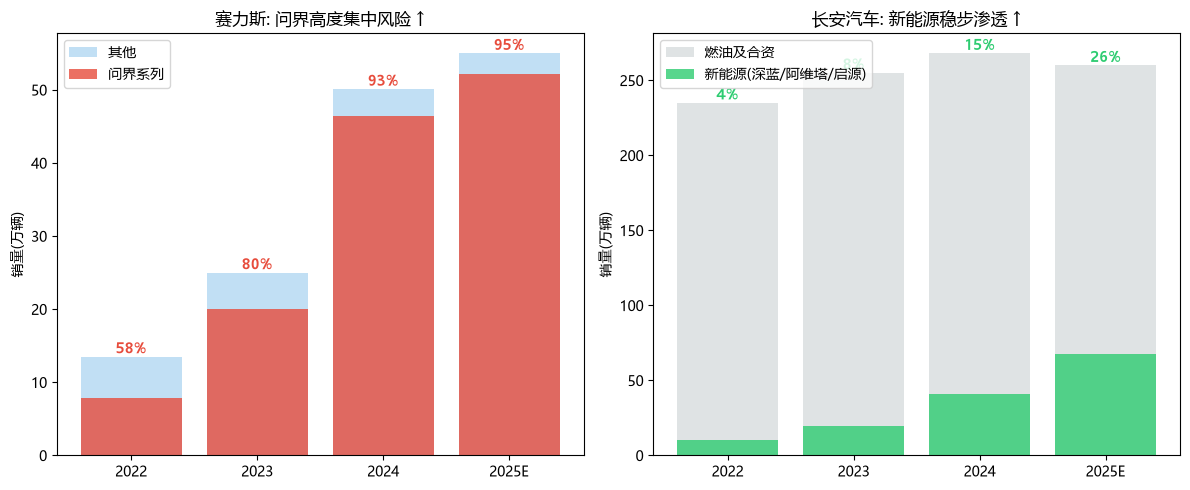


结论: 赛力斯高度依赖问界单一系列(集中风险↑), 长安多品牌均衡(抗风险能力↑)


In [35]:
# ============ 销量结构对比 ============
# 赛力斯: 问界占比 ~92.8%(2024)
# 长安: 新能源占比 ~15.3%(2024), 多品牌矩阵

sales_data = {
    '年份': ['2022', '2023', '2024', '2025E'],
    '赛力斯_总销(万)': [13.5, 25.0, 50.1, 55],
    '赛力斯_问界占比': [57.8, 80.0, 92.8, 95.0],
    '长安_总销(万)': [235, 255, 268, 260],
    '长安_新能源占比': [4.5, 7.8, 15.3, 26.0],
}
df_sales = pd.DataFrame(sales_data).set_index('年份')

print('='*60)
print('  销量结构对比: 赛力斯(高度集中) vs 长安(多品牌均衡)')
print('='*60)
print(df_sales.to_string())
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左: 问界集中度趋势
ax1.bar(df_sales.index, df_sales['赛力斯_总销(万)'], color='#3498DB', alpha=0.3, label='其他')
ax1.bar(df_sales.index, df_sales['赛力斯_总销(万)'] * df_sales['赛力斯_问界占比'] / 100,
        color='#E74C3C', alpha=0.8, label='问界系列')
ax1.set_title('赛力斯: 问界高度集中风险 ↑', fontsize=12)
ax1.set_ylabel('销量(万辆)')
ax1.legend()
for i, (idx, row) in enumerate(df_sales.iterrows()):
    ax1.annotate(f'{row["赛力斯_问界占比"]:.0f}%', (i, row['赛力斯_总销(万)']),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#E74C3C')

# 右: 长安新能源渗透率
ax2.bar(df_sales.index, df_sales['长安_总销(万)'], color='#95A5A6', alpha=0.3, label='燃油及合资')
ax2.bar(df_sales.index, df_sales['长安_总销(万)'] * df_sales['长安_新能源占比'] / 100,
        color='#2ECC71', alpha=0.8, label='新能源(深蓝/阿维塔/启源)')
ax2.set_title('长安汽车: 新能源稳步渗透 ↑', fontsize=12)
ax2.set_ylabel('销量(万辆)')
ax2.legend()
for i, (idx, row) in enumerate(df_sales.iterrows()):
    ax2.annotate(f'{row["长安_新能源占比"]:.0f}%', (i, row['长安_总销(万)']),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ECC71')

plt.tight_layout()
plt.show()

print('\n结论: 赛力斯高度依赖问界单一系列(集中风险↑), 长安多品牌均衡(抗风险能力↑)')
